In [1]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
from scipy.stats import gaussian_kde

## set default matplotlib font and font size
typeface='helvetica'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22

import os,random
from itertools import permutations

import sys
#sys.path.append('/Users/nmueller/Documents/github/CoInfection-Material/Applications/NetworkViz/')
import baltic_bacter as bt
print('loaded')

import pandas as pd

/Users/nmueller/Documents/github/CoInfection-Material/Applications/NetworkViz/baltic_bacter.py:780: SyntaxWarning: invalid escape sequence '\('
  cerberus=re.match('(\(|,)([0-9]+)(\[|\:)',data[i-1:i+100]) ## look for tips in BEAST format (integers).
/Users/nmueller/Documents/github/CoInfection-Material/Applications/NetworkViz/baltic_bacter.py:787: SyntaxWarning: invalid escape sequence '\('
  cerberus=re.match('(\(|,)(\'|\")*([A-Za-z\_\-\|\.0-9\?\/ ]+)(\'|\"|)(\[)*',data[i-1:i+200])  ## look for tips with unencoded names - if the tips have some unusual format you'll have to modify this
/Users/nmueller/Documents/github/CoInfection-Material/Applications/NetworkViz/baltic_bacter.py:794: SyntaxWarning: invalid escape sequence '\)'
  cerberus=re.match('\)([0-9]+)\[',data[i-1:i+100]) ## look for multitype tree singletons.
/Users/nmueller/Documents/github/CoInfection-Material/Applications/NetworkViz/baltic_bacter.py:800: SyntaxWarning: invalid escape sequence '\('
  cerberus=re.match('[\(,](#

loaded


/Users/nmueller/Documents/github/CoInfection-Material/Applications/H5N1NorthAmerica/combined/HPAI_HLHxNx.glm.tree
/opt/homebrew/Caskroom/miniconda/base/envs/plasmids/bin/python
/Users/nmueller/Documents/github/CoInfection-Material/Applications/H5N1NorthAmerica/combined/HPAI_HLHxNx.glm.log
2025.5


/var/folders/ws/xcw4gvzj7dj3pvst350g611c0000gn/T/ipykernel_61902/4043356819.py:363: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


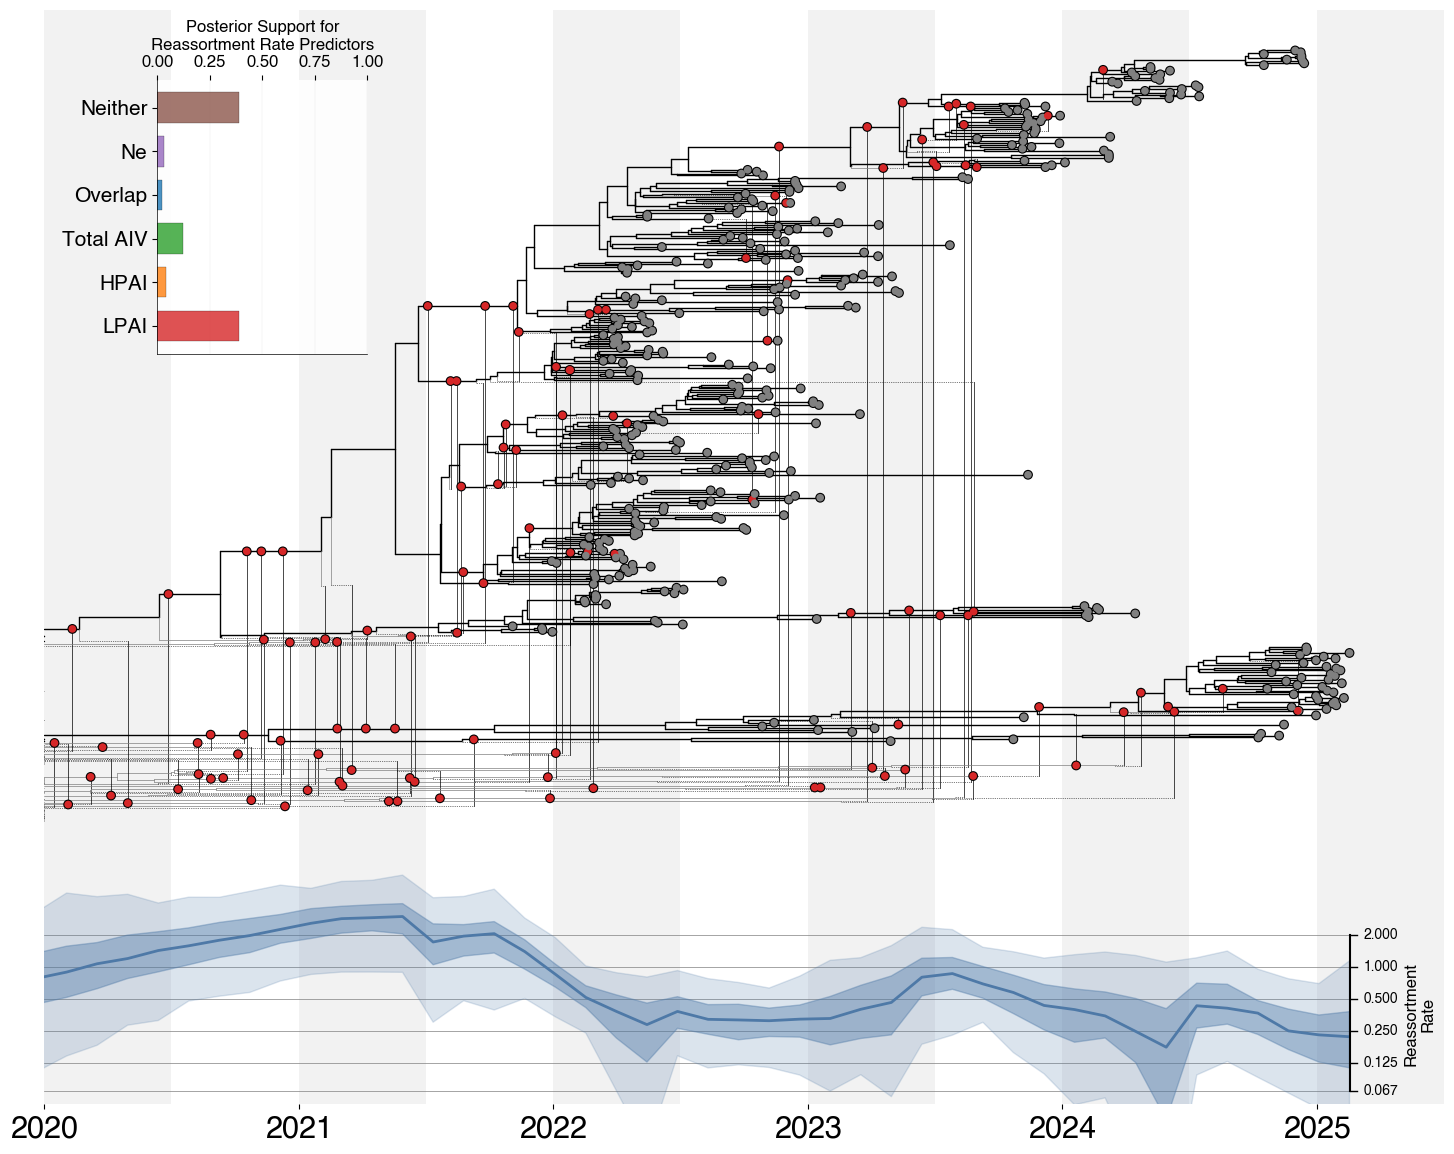

H5N1_glm_combined.pdf


In [150]:
colours = {'red', 'green'}

segments = ['HA', 'NA', 'MP', 'NS', 'NP', 'PB1', 'PB2', 'PA']

new_order = [0, 1, 2, 4, 7, 5, 6, 3]

colour_cycle = ['#969696', '#737373', '#525252', '#252525']
# colour_cycle = ["#b3cde3", "#8cadd1", "#6497b1", "#005b96", "#03396c"]

path = '/Users/nmueller/Documents/github/CoInfection-Material/Applications/H5N1NorthAmerica/'

linewidth = 0.5
approach = 'glm'
# Modified gridspec configuration for side-by-side layout
fig = plt.figure(figsize=(15, 12), facecolor='w')  # Increased width for side-by-side layout

# Modified subplot configuration - remove separate bar plot
gs = fig.add_gridspec(1, 1) 
                      # width_ratios=[3],  # Left column 3x wider than right
                      # height_ratios=[1],  # Adjusted ratios
                      # hspace=0.0,  # More vertical spacing
                      # wspace=0)  # Horizontal spacing between columns

# Create subplots (no separate ax_bar)
ax = fig.add_subplot(gs[0, 0], facecolor='w')  # Tree in top left
# ax_rates = fig.add_subplot(gs[1, 0], facecolor='w')  # Rates below tree
# ax_detect = fig.add_subplot(gs[0, 1], facecolor='w')  # Top right
# ax_ne = fig.add_subplot(gs[1, 0], facecolor='w')  # Bottom left

c1 = 0
c2 = 0    
# filename of type H5N1_wgs_proportional.constant.combined.0_7.reassortment
file = 'combined/HPAI_HLHxNx.' + approach + '.tree'
tree_path = os.path.join(path, file)
print(tree_path)
ll = bt.loadNexus(tree_path, date_fmt='%Y-%m-%d', verbose=False)  # load tree
seg_count = 0
ll.drawTree()
c2 += 1
if c2 == 2:
    c1 += 1
    c2 = 0

ax.set_facecolor('w')
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc != 'bottom']  # remove axis spines

fromval = float(int(ll.root.absoluteTime + ll.treeHeight)) - 5
toval = float(int(ll.root.absoluteTime + ll.treeHeight)) + 0.5

timewidth=0.5
# for i in np.arange(ll.root.absoluteTime - 1, ll.root.absoluteTime + ll.treeHeight + 1, 1.0):
#     ax.axvline(i, ls='-', color='lightgrey', lw=1, alpha=0.2)  # Add timeline
for i in np.arange(fromval, toval, 2 * timewidth):
    ax.axvspan(i, i + timewidth, facecolor='#F2F2F2', edgecolor='none', alpha=1, zorder=0)  # Add timeline

for k in ll.Objects:
    k.traits['re'] = 0

curr_traits_number = 0

# Collect reassortment events for rate calculation
reassortment_events = []

for k in sorted(ll.Objects, key=lambda w: w.height):  # iterate through branches, starting with oldest ones
    if hasattr(k, 'contribution'):  # if branch is the result of reassortment
        # pick a number at random between 0 and len(colour_cycle) that is not == w.traits['re']
        random_number = random.randint(0, len(colour_cycle) - 1)
        while random_number == k.traits['re']:
            random_number = random.randint(0, len(colour_cycle) - 1)

        subtree = ll.traverse_tree(k.children[-1], include_condition=lambda w: True)  # traverse the subtree
        for w in subtree:  # for every branch in subtree
            w.traits['re'] = random_number

for k in ll.Objects:  # iterate over branches
    x = k.absoluteTime
    xp = k.parent.absoluteTime
    if xp != None:
        xp = max(xp, fromval+0.000001)
    y = k.y
    col = colour_cycle[k.traits['re'] % len(colour_cycle)]  # get colour out of colour cycle
    col = 'black'
    if isinstance(k, bt.reticulation) == False:  # if a regular branch
        col_lin = 'grey'
        lw_scale = 1
        if k.traits['seg0']=='true':
            col_lin='black'
            lw_scale=2
        
        ax.plot([x, xp], [y, y], color=col_lin, lw=linewidth*lw_scale, solid_capstyle='round')
    else:
        ax.plot([x, xp], [y, y], color=col, lw=linewidth, ls=':', solid_capstyle='round')  # reassortment branches are black

    if k.branchType == 'node':  # if node - plot vertical bar
        left, right = k.children[-1].y, k.children[0].y
        
        col_lin1 = 'grey'
        lw_scale1 = 1
        col_lin2 = 'grey'
        lw_scale2 = 1

        if k.children[-1].traits['seg0']=='true':
            col_lin1='black'
            lw_scale1=2

        if k.children[0].traits['seg0']=='true':
            col_lin2='black'
            lw_scale2=2


        # col1 = colour_cycle[k.children[-1].traits['re'] % len(colour_cycle)]  # get colour out of colour cycle
        # col2 = colour_cycle[k.children[0].traits['re'] % len(colour_cycle)]  # get colour out of colour cycle
        ax.plot([x, x], [left, k.y], color=col_lin1, lw=linewidth*lw_scale1, solid_capstyle='round')
        ax.plot([x, x], [k.y, right], color=col_lin2, lw=linewidth*lw_scale2, solid_capstyle='round')

    elif isinstance(k, bt.leaf):  # if actual leaf - add circle
        ax.scatter(x, y, s=50, facecolor='black', edgecolor='none', zorder=4)
        ax.scatter(x, y, s=30, facecolor='grey', edgecolor='none', zorder=5)

    elif isinstance(k, bt.reticulation):  # dealing with reassortant branch
        segs = sorted(map(int, k.traits['segments']))  # get travelling segment(s)
        
        # Store reassortment event timing
        reassortment_events.append({
            'time': x,
            'segments': segs,
            'posterior': k.traits.get('posterior', 1.0)
        })

        # color_key = k.traits['seg1'] + '+' + k.traits['seg4'] + '+' +  k.traits['seg6']
        
        ax.scatter(x, k.target.y, s=50, facecolor="black", edgecolor='none', zorder=4)
        ax.scatter(x, k.target.y, s=30, facecolor="#d62728", edgecolor='none', zorder=5)
        ax.plot([x, x], [y, k.target.y], color=col, lw=linewidth, ls='-', solid_capstyle='round')  # plot vertical lineage leaving donor and heading to recipient

        for i in range(len(segs)):
            name = segs[i]  # get name of segment
            c = 'black'  # get appropriate colour
            o = 1 / 20.
            posterior_val = round(k.traits['posterior'], 2)

ax.set_yticks([])
#x_ticks=np.arange(fromval, toval, 2)
# ax.set_xticks(x_ticks)
#ax.set_xticks([])
# ax.tick_params(axis='x',labelsize=25)

ax.set_ylim(ll.ySpan * 1.01+150, -ll.ySpan * 0.05)
ax.set_xlim(fromval, toval)
# ax.set_xlim(2014, toval)

ax.spines['bottom'].set_visible(False)

# Read log file (similar to R script approach)
log_file_path = os.path.join(path, 'combined/HPAI_HLHxNx.' + approach +'.log')

import sys
print(sys.executable)

print(log_file_path)
# Read the log file
import pandas as pd
log_data = pd.read_csv(log_file_path, sep='\t')

# Define rate shifts (same as R script)
rate_shifts = [0, 0.12, 0.24, 0.36, 0.48, 0.6, 0.72, 0.84, 0.96, 1.08, 1.2, 1.32, 1.44, 1.56, 1.68, 1.8, 1.92, 2.04, 2.16, 2.28, 2.4, 2.52, 2.64, 2.76, 2.88, 3, 3.12, 3.24, 3.36, 3.48, 3.6, 3.72, 3.84, 3.96, 4.08, 4.2, 4.32, 4.44, 4.56, 4.68, 4.8, 4.92, 5.04, 5.16, 5.28, 5.4, 5.52, 5.64, 5.76, 5.88, 6, 6.8, 7.6, 8.4, 9.2, 10]    

# Calculate time points for plotting (convert from years before present to calendar time)
mrsi = 2025.12877
time_points = [mrsi - shift for shift in rate_shifts[:-1]]  # Exclude last infinite value

# Calculate quantiles for each time point
quantiles_to_plot = [0.05, 0.25, 0.5, 0.75, 0.95]  # 5%, 25%, 50%, 75%, 95%
colors_quantiles = ['#E8F4FD', '#B3D9F2', '#4E79A7', '#B3D9F2', '#E8F4FD']

# Collect all median values for smooth plotting
medians = []
lower_95 = []
upper_95 = []
lower_50 = []
upper_50 = []
valid_times = []

medians_ne  = []
lower_95_ne = []
upper_95_ne = []
lower_50_ne = []
upper_50_ne = []
for i, shift in enumerate(rate_shifts[:-1]):
    if i >= len(time_points):
        break
        
    col_name = f'reassortmentRate.{i}'
    col_name2 = f'logNe.{i+1}'
    rates_at_time = log_data[col_name].values
    ne_at_time = log_data[col_name2].values
    
    medians.append(np.quantile(rates_at_time, 0.5))
    lower_95.append(np.quantile(rates_at_time, 0.025))
    upper_95.append(np.quantile(rates_at_time, 0.975))
    lower_50.append(np.quantile(rates_at_time, 0.25))
    upper_50.append(np.quantile(rates_at_time, 0.75))
    valid_times.append(time_points[i])
    
    medians_ne.append(np.quantile(ne_at_time, 0.5))
    lower_95_ne.append(np.quantile(ne_at_time, 0.025))
    upper_95_ne.append(np.quantile(ne_at_time, 0.975))
    lower_50_ne.append(np.quantile(ne_at_time, 0.25))
    upper_50_ne.append(np.quantile(ne_at_time, 0.75))

    
offset_y =500.
stretch_y = -25
# Convert to numpy arrays for arithmetic operations
medians = np.array(medians)*stretch_y+offset_y
lower_95 = np.array(lower_95)*stretch_y+offset_y
upper_95 = np.array(upper_95)*stretch_y+offset_y
lower_50 = np.array(lower_50)*stretch_y+offset_y
upper_50 = np.array(upper_50)*stretch_y+offset_y


ax.fill_between(valid_times, lower_95, upper_95, alpha=0.2, color='#4E79A7', label='95% CI', zorder=2)
ax.fill_between(valid_times, lower_50, upper_50, alpha=0.4, color='#4E79A7', label='50% CI', zorder=2)
ax.plot(valid_times, medians, color='#4E79A7', linewidth=2, label='Median', zorder=2)

axis_time = time_points[0]  # Time point for i=0

# Define the rate range you want to show (-5 to 1)
rate_range = np.log([0.0675, 0.125, 0.25,0.5,1,2])  # -5 to 1 in steps of 1

# Transform rate values to plot coordinates
axis_y_positions = rate_range * stretch_y + offset_y

# Draw the vertical axis line
ax.plot([axis_time, axis_time], [axis_y_positions[0], axis_y_positions[-1]], 
        color='black', linewidth=1.5, zorder=10)

# Add tick marks and labels on the right side
for i, (rate_val, y_pos) in enumerate(zip(rate_range, axis_y_positions)):
    # Draw tick mark (extending to the right)
    tick_length = (toval - fromval) * 0.005  # 1% of x-axis range
    ax.plot([axis_time, axis_time + tick_length], [y_pos, y_pos], 
            color='black', linewidth=1, zorder=10)
    
    # Add horizontal grid line across the plot
    ax.plot([fromval, axis_time], [y_pos, y_pos], 
            color='grey', linewidth=0.5, alpha=1, linestyle='-', zorder=1)

    # Add label on the right side
    ax.text(axis_time + tick_length * 2, y_pos, f'{np.exp(rate_val):.3f}', 
            ha='left', va='center', fontsize=10, zorder=10)

# Add axis label on the right side
label_y = np.mean(axis_y_positions)
ax.text(axis_time + (toval - fromval) * 0.05, label_y, 'Reassortment\nRate', 
        ha='center', va='center', fontsize=12, rotation=90, zorder=10)

#ax_rates.legend(fontsize=10, loc='upper right')

# ax_ne.fill_between(valid_times, lower_95_ne, upper_95_ne, alpha=0.2, color='#4E79A7', label='95% CI')
# ax_ne.fill_between(valid_times, lower_50_ne, upper_50_ne, alpha=0.4, color='#4E79A7', label='50% CI')
# ax_ne.plot(valid_times, medians_ne, color='#4E79A7', linewidth=2, label='Median')
# # ax_ne.legend(fontsize=10, loc='upper right')


# # Add timeline shading to match the tree
# for i in np.arange(fromval, toval, 2 * timewidth):
#     # ax_rates.axvspan(i, i + timewidth, facecolor='#F2F2F2', edgecolor='none', alpha=1, zorder=0)
#     ax_ne.axvspan(i, i + timewidth, facecolor='#F2F2F2', edgecolor='none', alpha=1, zorder=0)

# Format reassortment rate plot
# ax.set_xlim(fromval, toval)
# ax.set_xlabel('Time', fontsize=20)
# ax.set_ylabel('Reassortment\nRate', fontsize=20)
# ax.tick_params(axis='both', labelsize=16)

# ax_ne.set_xlim(fromval, toval)
# ax_ne.set_xlabel('Time', fontsize=20)
# ax_ne.set_ylabel('Ne', fontsize=20)
# ax_ne.tick_params(axis='both', labelsize=16)


# Set y-axis to log scale if using log data (similar to R script)
# ax_rates.set_yscale('log')
# ax_rates.set_ylim(0.05, 5)  # Adjust based on your data range

# Set x-ticks to match the tree
# ax_rates.set_xticks(x_ticks)
# xtick_labels = [f"{t:.0f}" for t in x_ticks]  
# ax_rates.set_xticklabels(xtick_labels, fontsize=16, rotation=0, ha='center')

# Style the rates plot
# ax_rates.spines['top'].set_visible(False)
# ax_rates.spines['right'].set_visible(False)
# ax_rates.spines['left'].set_linewidth(1)
# ax_rates.spines['bottom'].set_linewidth(1)

# Add grid for better readability
# ax_rates.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
# ax_rates.set_axisbelow(True)
print(toval)
ax.set_xlim(fromval, toval)


# Create inset axes in the top-left corner of the tree plot
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ax_bar_inset = inset_axes(ax, width="15%", height="25%", loc='upper left', 
                          bbox_to_anchor=(0.07, -0.05, 1, 1), bbox_transform=ax.transAxes)

predictor_counts = log_data['predictorActive'].value_counts().sort_index()

# Define labels for predictor values
predictor_labels = {
    0: 'LPAI',
    1: 'HPAI', 
    2: 'Total AIV',
    3: 'Overlap',
    4: 'Ne',
    5: 'Neither'
}
# Ensure all categories are represented (fill with 0 if missing)
categories = list(range(6))
counts = [predictor_counts.get(i, 0) for i in categories]
labels = [predictor_labels[i] for i in categories]

# Create horizontal bar plot (flipped x and y axes)
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b']
bars = ax_bar_inset.barh(labels, counts/sum(counts), color=colors, alpha=0.8, 
                        edgecolor='black', linewidth=0.2, height=0.7)

# Format the inset bar plot
ax_bar_inset.set_xlabel('Posterior Support for\nReassortment Rate Predictors', fontsize=12)
ax_bar_inset.tick_params(axis='both', labelsize=12)
ax_bar_inset.tick_params(axis='y', labelsize=15)

# # Add value labels on bars (now at the end of each bar)
# for bar, count in zip(bars, counts):
#     if count > 0:
#         ax_bar_inset.text(bar.get_width() +1*0.02, 
#                          bar.get_y() + bar.get_height()/2,
#                          f'{count/sum(count)}', ha='left', va='center', fontsize=7)

ax_bar_inset.xaxis.set_ticks_position('top')
ax_bar_inset.xaxis.set_label_position('top')

# Style the inset bar plot
ax_bar_inset.spines['top'].set_visible(False)
ax_bar_inset.spines['right'].set_visible(False)
ax_bar_inset.spines['left'].set_linewidth(0.5)
ax_bar_inset.spines['bottom'].set_linewidth(0.5)
ax_bar_inset.grid(True, alpha=0.3, linestyle='-', linewidth=0.3, axis='x')
ax_bar_inset.set_axisbelow(True)
ax_bar_inset.set_xlim(0,1)
# Set background to white with slight transparency
ax_bar_inset.patch.set_facecolor('white')
ax_bar_inset.patch.set_alpha(0.9)

# Optional: Add a border around the inset
for spine in ax_bar_inset.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()
figname = 'H5N1_' + approach + '_combined.pdf'
print(figname)
fig.savefig(figname, bbox_inches='tight', pad_inches=0.1)


plt.close(fig)


In [111]:



detections_df = pd.read_csv('combined/HPAI_detections_date.csv', parse_dates=['date_det'])
detections_df = detections_df.sort_values('date_det')

def to_decimal_year(d):
    year = d.year
    start_of_year = pd.Timestamp(year=year, month=1, day=1)
    year_length = (pd.Timestamp(year=year+1, month=1, day=1) - start_of_year).days
    return year + ((d - start_of_year).days) / year_length

window_size = 7
detections_df['decimal_year'] = detections_df['date_det'].apply(to_decimal_year)
detections_df['rolling_mean'] = detections_df['total_counts'].rolling(window=window_size, center=True, min_periods=1).mean()
detections_df['rolling_std'] = detections_df['total_counts'].rolling(window=window_size, center=True, min_periods=1).std()
detections_df['rolling_se'] = detections_df['rolling_std'] / np.sqrt(window_size)
detections_df['lower_CI'] = detections_df['rolling_mean'] - 1.96 * detections_df['rolling_se']
detections_df['upper_CI'] = detections_df['rolling_mean'] + 1.96 * detections_df['rolling_se']


ax_detect.plot(
    detections_df['decimal_year'],
    detections_df['rolling_mean'],
    color='#4E79A7',
    lw=2,
    label='7-day Moving Avg'
)
# Plot confidence interval ribbon
ax_detect.fill_between(
    detections_df['decimal_year'],
    detections_df['lower_CI'],
    detections_df['upper_CI'],
    color='#4E79A7',
    alpha=0.2,
    label='95% CI'
)

# Add shading to match other panels
# Add timeline shading
for i in np.arange(fromval, toval, 2 * timewidth):
    ax_detect.axvspan(i, i + timewidth, facecolor='#F2F2F2', edgecolor='none', alpha=1, zorder=0)

ax_detect.set_xlim(fromval, toval)
ax_detect.set_xlabel('Time', fontsize=20)
ax_detect.set_ylabel('Total Detections', fontsize=20)
ax_detect.tick_params(axis='both', labelsize=16)

ax_detect.set_xticks(x_ticks)
ax_detect.set_xticklabels(xtick_labels, fontsize=16, rotation=0, ha='center')

ax_detect.spines['top'].set_visible(False)
ax_detect.spines['right'].set_visible(False)
ax_detect.spines['left'].set_linewidth(1)
ax_detect.spines['bottom'].set_linewidth(1)
ax_detect.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax_detect.set_axisbelow(True)
ax_detect.legend()




plt.tight_layout()
plt.show()
figname = 'H5N1_' + approach + '_combined.pdf'
print(figname)
fig.savefig(figname, bbox_inches='tight')
plt.close(fig)

FileNotFoundError: [Errno 2] No such file or directory: 'combined/HPAI_detections_date.csv'